<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 131 · Forecasting Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Forecasting Retail Sales</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">The full 12-step forecasting workflow on nine years of monthly retail sales: inspect and clean a bad data point, decompose trend and seasonality, test stationarity, beat a seasonal-naive baseline, fit and grade Holt-Winters and SARIMA out of sample, and deploy the winner to forecast the next 12 months with a prediction interval.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Case Study: Forecasting Retail Sales
This is the flagship forecasting project, the whole toolkit of Part XXII on one real series. We take nine years of monthly retail sales and run the full 12-step method: inspect and clean, decompose into trend and seasonality, check stationarity, set a baseline, fit Holt-Winters and SARIMA, grade them honestly on a held-out year, and finally refit and forecast the next 12 months with a prediction interval. Everything runs on **statsmodels**.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings('ignore')
def mape(a,f): return float(np.mean(np.abs((a.values-np.asarray(f))/a.values))*100)

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 1 &#183; DEFINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What are we forecasting, and why?</div>
<div style="color:#4a5578;margin-top:6px">A number is useless without a decision and a bar to clear.</div>
</div>

A retailer needs a **12-month sales forecast** to plan inventory, staffing, and budgets. Success is concrete: the forecast must **beat a seasonal-naive baseline** (repeat last year), keep error low (**MAPE**), and come with an **honest uncertainty band**, a single point estimate is a false promise for planning a year out.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 &#183; COLLECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Load the monthly series</div>
<div style="color:#4a5578;margin-top:6px">One value per month, in order.</div>
</div>

In [3]:
try: raw = pd.read_excel('../../data/ch131_retail_sales.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'ch131_retail_sales.xlsx', sheet_name='Data')
raw['month']=pd.to_datetime(raw['month']); s = raw.set_index('month')['sales'].asfreq('MS')
print('points:', len(s), '| from', s.index.min().date(), 'to', s.index.max().date())
s.head(3)

points: 108 | from 2016-01-01 to 2024-12-01


month
2016-01-01    81810
2016-02-01    84044
2016-03-01    91776
Freq: MS, Name: sales, dtype: int64

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 3 &#183; INSPECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Look before you model</div>
<div style="color:#4a5578;margin-top:6px">Plot first; the eye catches what summaries miss.</div>
</div>

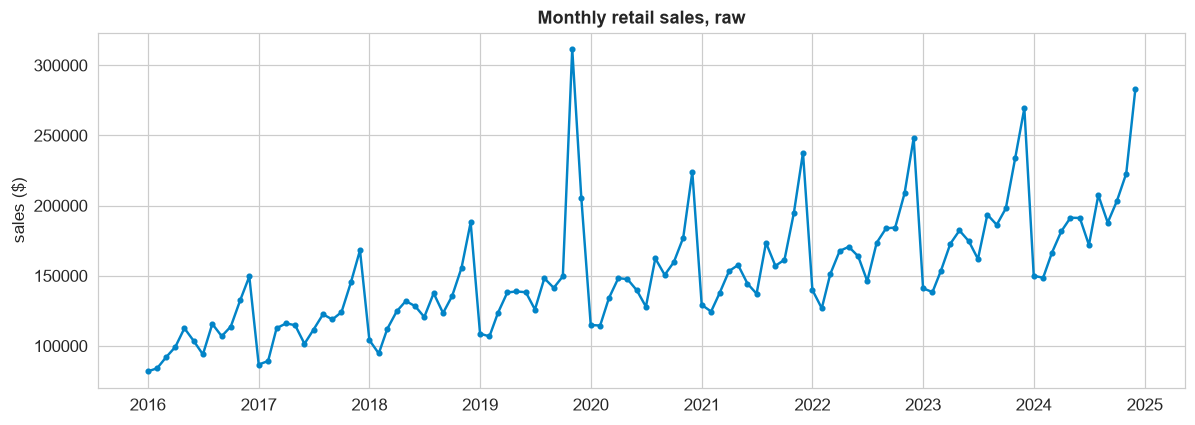

clear upward trend + a yearly wave peaking each December... and one implausible spike in late 2019


In [4]:
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(s.index, s.values, color=EM, lw=1.6, marker='o', ms=3)
ax.set(title='Monthly retail sales, raw', ylabel='sales ($)'); plt.tight_layout(); plt.show()
print('clear upward trend + a yearly wave peaking each December... and one implausible spike in late 2019')

Two features are obvious, a rising **trend** and a repeating yearly **season** with a December peak. But one month spikes far above its neighbors: a likely **data-entry error** that would poison any model. Inspect before you trust.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 4 &#183; CLEAN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fix the error month</div>
<div style="color:#4a5578;margin-top:6px">Detect the outlier, replace it with a sensible value.</div>
</div>

In [5]:
med = s.rolling(13, center=True, min_periods=3).median()
err = (s - med).abs().idxmax()
print('outlier: %s = $%d  (neighbors median $%d)' % (err.date(), s[err], med[err]))
clean = s.copy(); clean[err] = np.nan; clean = clean.interpolate()
print('replaced with interpolated value $%d' % clean[err])

outlier: 2019-11-01 = $311638  (neighbors median $141367)
replaced with interpolated value $177427


A **rolling-median** check flags the month that sits farthest from its local neighbors, here <strong>November 2019</strong>, roughly double what the surrounding months suggest. We blank it and **interpolate** from its neighbors. From here on we model the cleaned series.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 5 &#183; DECOMPOSE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Split into trend, season, and noise</div>
<div style="color:#4a5578;margin-top:6px">See the pieces the model must capture.</div>
</div>

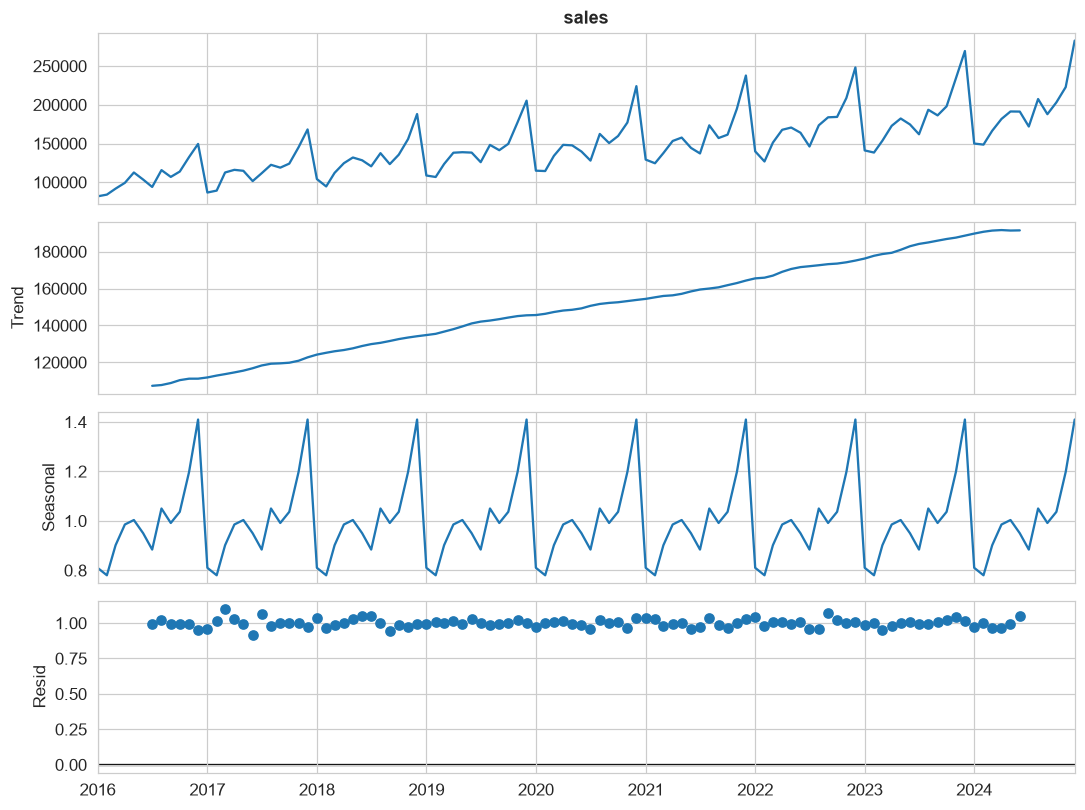

trend: about $963 per month (~$11564 per year)
seasonal: December 1.41x (peak), February 0.78x (trough)


In [6]:
dec = seasonal_decompose(clean, model='multiplicative', period=12)
fig = dec.plot(); fig.set_size_inches(10,7.5); plt.tight_layout(); plt.show()
slope = np.polyfit(np.arange(len(clean)), clean.values, 1)[0]
sf = dec.seasonal.groupby(dec.seasonal.index.month).mean()
print('trend: about $%d per month (~$%d per year)' % (slope, slope*12))
print('seasonal: December %.2fx (peak), February %.2fx (trough)' % (sf[12], sf[2]))

Decomposition confirms the story: the trend adds roughly <strong>$960 a month</strong>, and December runs about <strong>41% above</strong> a typical month while February sits about 22% below. The swing grows with the level, so this is <strong>multiplicative</strong> seasonality, which will steer our model choice.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 6 &#183; CHECK STATIONARITY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Is the mean stable over time?</div>
<div style="color:#4a5578;margin-top:6px">Most models assume it; this series fails, then passes.</div>
</div>

In [7]:
print('ADF raw           p = %.3f -> %s' % (adfuller(clean)[1], 'stationary' if adfuller(clean)[1]<0.05 else 'NON-stationary'))
print('ADF differenced   p = %.3f -> %s' % (adfuller(clean.diff().dropna())[1], 'stationary' if adfuller(clean.diff().dropna())[1]<0.05 else 'NON-stationary'))

ADF raw           p = 0.896 -> NON-stationary
ADF differenced   p = 0.000 -> stationary


The raw series is <strong>non-stationary</strong> (ADF p about 0.90) because its mean trends up. One <strong>difference</strong> removes the trend and it passes (p about 0.00). That is the <strong>I</strong> in ARIMA, and it is why SARIMA below uses d = 1.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 7 &#183; SPLIT &amp; BASELINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Hold out the last year, set the bar</div>
<div style="color:#4a5578;margin-top:6px">Fit on the past, judge on the unseen future.</div>
</div>

In [8]:
train, test = clean[:-12], clean[-12:]
snaive = train.iloc[-12:].values
print('train %d months | test %d months' % (len(train), len(test)))
print('seasonal-naive baseline MAPE: %.2f%%  <- every model must beat this' % mape(test, snaive))

train 96 months | test 12 months
seasonal-naive baseline MAPE: 5.37%  <- every model must beat this


We split <strong>in time</strong>, 96 months to train, the last 12 to test, so the evaluation mimics real forecasting. The <strong>seasonal-naive</strong> forecast (same month last year) already captures the seasonality and scores about <strong>5.4% MAPE</strong>. That is the number to beat.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 8 &#183; MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit Holt-Winters and SARIMA</div>
<div style="color:#4a5578;margin-top:6px">Two families, one held-out test.</div>
</div>

In [9]:
hw = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit()
sar = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
hw_fc, sar_fc = hw.forecast(12), sar.forecast(12)
print('Holt-Winters (multiplicative) fitted; SARIMA(1,1,1)(1,1,1,12) AIC %.0f' % sar.aic)

Holt-Winters (multiplicative) fitted; SARIMA(1,1,1)(1,1,1,12) AIC 1416


Two workhorses. <strong>Holt-Winters</strong> smooths a level, a trend, and a <strong>multiplicative</strong> season, matching what decomposition showed. <strong>SARIMA</strong> models the autocorrelations after differencing and returns a prediction interval for free.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 9 &#183; VALIDATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Grade them on the holdout</div>
<div style="color:#4a5578;margin-top:6px">Several metrics, and the winner.</div>
</div>

In [10]:
def rmse(a,f): return float(np.sqrt(np.mean((a.values-np.asarray(f))**2)))
def mae(a,f): return float(np.mean(np.abs(a.values-np.asarray(f))))
nmae = mae(test, snaive)
rows=[]
for name,f in [('seasonal-naive',snaive),('Holt-Winters',hw_fc),('SARIMA',sar_fc)]:
    rows.append({'model':name,'MAE':round(mae(test,f)),'RMSE':round(rmse(test,f)),'MAPE_%':round(mape(test,f),2),'MASE':round(mae(test,f)/nmae,2)})
res = pd.DataFrame(rows); print(res.to_string(index=False))
best = res.sort_values('MAPE_%').iloc[0]['model']; print('\nwinner by MAPE:', best)

         model   MAE  RMSE  MAPE_%  MASE
seasonal-naive 10143 10851    5.37  1.00
  Holt-Winters  4498  6184    2.34  0.44
        SARIMA  9070 11383    4.88  0.89

winner by MAPE: Holt-Winters


The verdict panel is clear: <strong>Holt-Winters wins at about 2.3% MAPE</strong>, less than half the baseline, with SARIMA a respectable runner-up near 4.9%. Both beat seasonal-naive (MASE below 1), but the multiplicative Holt-Winters fits this multiplicative series best. We choose it.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 10 &#183; INTERPRET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Trust it only if the residuals are clean</div>
<div style="color:#4a5578;margin-top:6px">A good forecast leaves behind white noise.</div>
</div>

Holt-Winters in-sample residual Ljung-Box p = 0.17 -> no leftover autocorrelation (good)


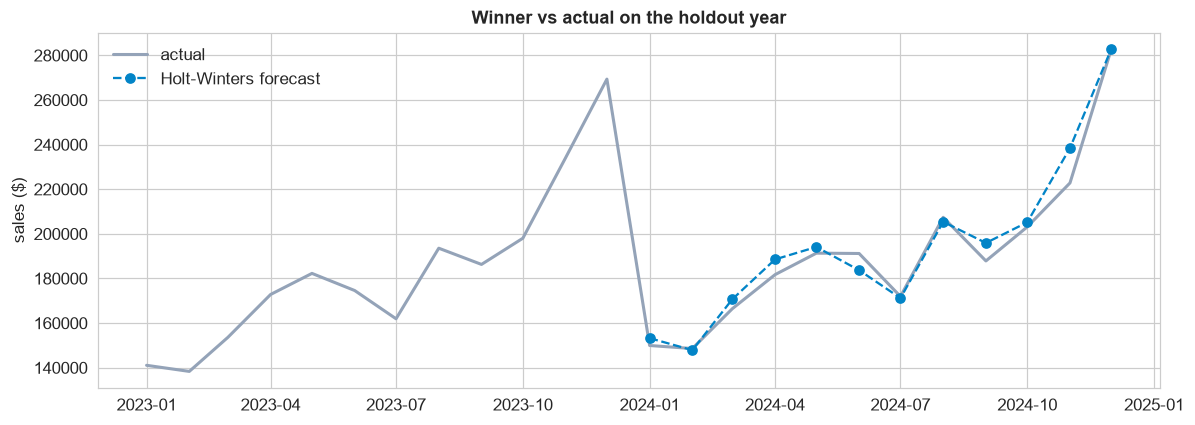

In [11]:
resid = test.values - np.asarray(hw_fc)
lb = acorr_ljungbox(hw.resid, lags=[12])['lb_pvalue'].iloc[0]
print('Holt-Winters in-sample residual Ljung-Box p = %.2f -> %s' % (lb, 'no leftover autocorrelation (good)' if lb>0.05 else 'structure remains'))
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(clean.index[-24:], clean.values[-24:], color=GREY, lw=2, label='actual')
ax.plot(test.index, hw_fc, 'o--', color=EM, label='Holt-Winters forecast')
ax.set(title='Winner vs actual on the holdout year', ylabel='sales ($)'); ax.legend(); plt.tight_layout(); plt.show()

The winner's <strong>residuals pass a Ljung-Box test</strong> (no autocorrelation left), meaning it captured the trend and season with no obvious signal wasted. Visually it tracks the holdout year tightly, including the December peak. Now we can deploy it.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 11 &#183; DEPLOY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Refit on ALL data, forecast the true future</div>
<div style="color:#4a5578;margin-top:6px">The model goes to production and predicts what nobody has seen.</div>
</div>

next-12-month forecast (refit on the full, cleaned history):
  total: $2.44M
  December 2025: $295955  (95% interval $269674 to $324174)


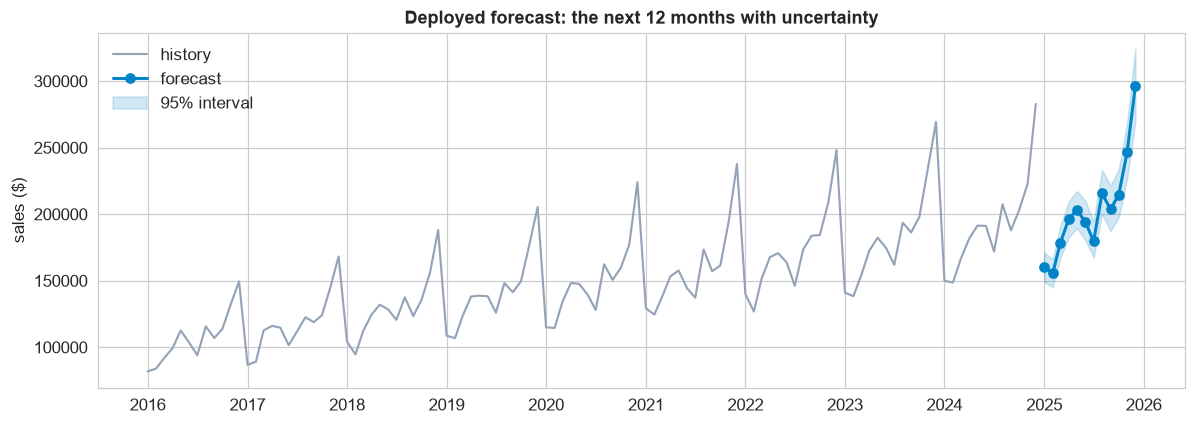

In [12]:
final = ExponentialSmoothing(clean, trend='add', seasonal='mul', seasonal_periods=12).fit()
future = final.forecast(12)
sims = final.simulate(12, repetitions=1000, error='mul')
lo, hi = sims.quantile(0.025, axis=1), sims.quantile(0.975, axis=1)
print('next-12-month forecast (refit on the full, cleaned history):')
print('  total: $%.2fM' % (future.sum()/1e6))
print('  December 2025: $%.0f  (95%% interval $%.0f to $%.0f)' % (future.iloc[11], lo.iloc[11], hi.iloc[11]))
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(clean.index, clean.values, color=GREY, lw=1.4, label='history')
ax.plot(future.index, future.values, 'o-', color=EM, lw=2, label='forecast')
ax.fill_between(future.index, lo, hi, color=EM, alpha=0.18, label='95% interval')
ax.set(title='Deployed forecast: the next 12 months with uncertainty', ylabel='sales ($)'); ax.legend(); plt.tight_layout(); plt.show()

Crucially, before forecasting the real future we <strong>refit on the entire cleaned history</strong> (holding out was only for grading). The model projects about <strong>$2.4M over the next 12 months</strong>, with the familiar December peak near <strong>$296k</strong> and a 95% interval of roughly $266k to $325k. That <strong>fan of uncertainty</strong>, not just the line, is what a planner should budget against, and in production you would rerun this each month as new sales arrive.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 12 &#183; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Say it in one paragraph</div>
<div style="color:#4a5578;margin-top:6px">The forecast is only useful if it is understood.</div>
</div>

<strong>For the planning team:</strong> after removing one bad data point, sales are growing about <strong>$960 a month</strong> with a strong, predictable December surge. Our chosen model (Holt-Winters) forecasts the next year at roughly <strong>$2.4M</strong>, and it is trustworthy, on the last twelve months it was accurate to about <strong>2.3%</strong>, well ahead of a naive last-year forecast. Plan against the <strong>range</strong>, not the single number, and expect December near $296k (anywhere from about $266k to $325k).

## The forecasting method, in one view

1. **Define** the decision and the baseline to beat.
2. **Collect** the series on a proper time index.
3. **Inspect** with a plot before modeling.
4. **Clean** the obvious errors (one bad month here).
5. **Decompose** into trend, season, and noise.
6. **Check stationarity** with ADF; difference if needed.
7. **Split in time** and set a seasonal-naive baseline.
8. **Model** with Holt-Winters and SARIMA.
9. **Validate** on the holdout with MAE/RMSE/MAPE/MASE.
10. **Interpret**: confirm the residuals are white noise.
11. **Deploy**: refit on all data, forecast ahead with an interval.
12. **Communicate** the result and its uncertainty in plain English.

**The one idea to keep: a forecast is a decision tool, so the workflow is not just fitting a model, it is cleaning honestly, beating a baseline, proving accuracy out of sample, and shipping a range the business can plan against.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>